## GROUP WORK

## PART 1

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm 


In [3]:
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")
chl

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [4]:
# Region boundaries
lon_min = -135
lon_max = -115
lat_min = 30
lat_max = 45

# Subset region
chl_region = chl.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

chl_region

<xarray.Dataset> Size: 4kB
Dimensions:  (time: 12, lat: 0, lon: 480)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 0B ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [11]:

bathy = xr.open_dataset("GMRTv4_4_1_20260512topo.grd")
print(bathy)


<xarray.Dataset> Size: 2MB
Dimensions:    (side: 2, xysize: 256022)
Dimensions without coordinates: side, xysize
Data variables:
    x_range    (side) float64 16B ...
    y_range    (side) float64 16B ...
    z_range    (side) float64 16B ...
    spacing    (side) float64 16B ...
    dimension  (side) int32 8B ...
    z          (xysize) float64 2MB ...
Attributes:
    title:    GMRT Grid
    source:   \n\tProjection: Cylindrical Equidistant\n\tCreated with GMRT Ma...


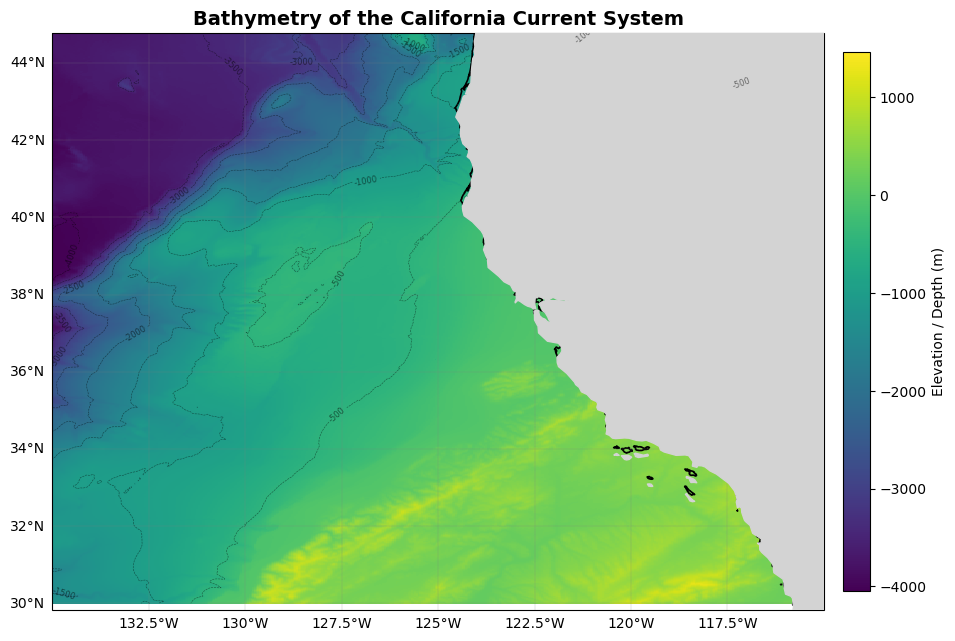

In [15]:
# --- reshape data ---
nx = int(bathy["dimension"].values[0])
ny = int(bathy["dimension"].values[1])

z = bathy["z"].values.reshape(ny, nx)

# --- build coordinate grid ---
x = np.linspace(lon_min, lon_max, nx)
y = np.linspace(lat_min, lat_max, ny)
X, Y = np.meshgrid(x, y)

# --- figure ---
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- main bathymetry field ---
im = ax.pcolormesh(
    X, Y, z,
    cmap="viridis",   # deeper = darker/more intense
    shading="auto",
    transform=ccrs.PlateCarree()
)

# --- contour lines (like your example image) ---
contours = ax.contour(
    X, Y, z,
    levels=np.arange(-5000, 0, 500),
    colors="black",
    linewidths=0.4,
    alpha=0.5,
    transform=ccrs.PlateCarree()
)

ax.clabel(contours, inline=True, fontsize=6, fmt="%d")

# --- coastline + land styling ---
ax.coastlines(resolution="10m", linewidth=1.2)
ax.add_feature(cfeature.LAND, color="lightgray", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# --- gridlines (like professional maps) ---
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- extent ---
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# --- colorbar ---
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Elevation / Depth (m)")

# --- title ---
ax.set_title("Bathymetry of the California Current System", fontsize=14, fontweight="bold")

plt.show()

## PART 2

In [17]:
chl_mean = chl_region["chlor_a"].mean(dim="time")
chl_mean

<xarray.DataArray 'chlor_a' (lat: 0, lon: 480)> Size: 0B
array([], shape=(0, 480), dtype=float32)
Coordinates:
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [19]:
print(type(chl_mean))
print(chl_mean)

<class 'xarray.core.dataarray.DataArray'>
<xarray.DataArray 'chlor_a' (lat: 0, lon: 480)> Size: 0B
array([], shape=(0, 480), dtype=float32)
Coordinates:
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


In [25]:
import xarray as xr

ds = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

In [26]:
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
  

In [27]:
chl = ds["chlor_a"]      # or whatever variable name appears
chl_mean = chl.mean(dim="time")

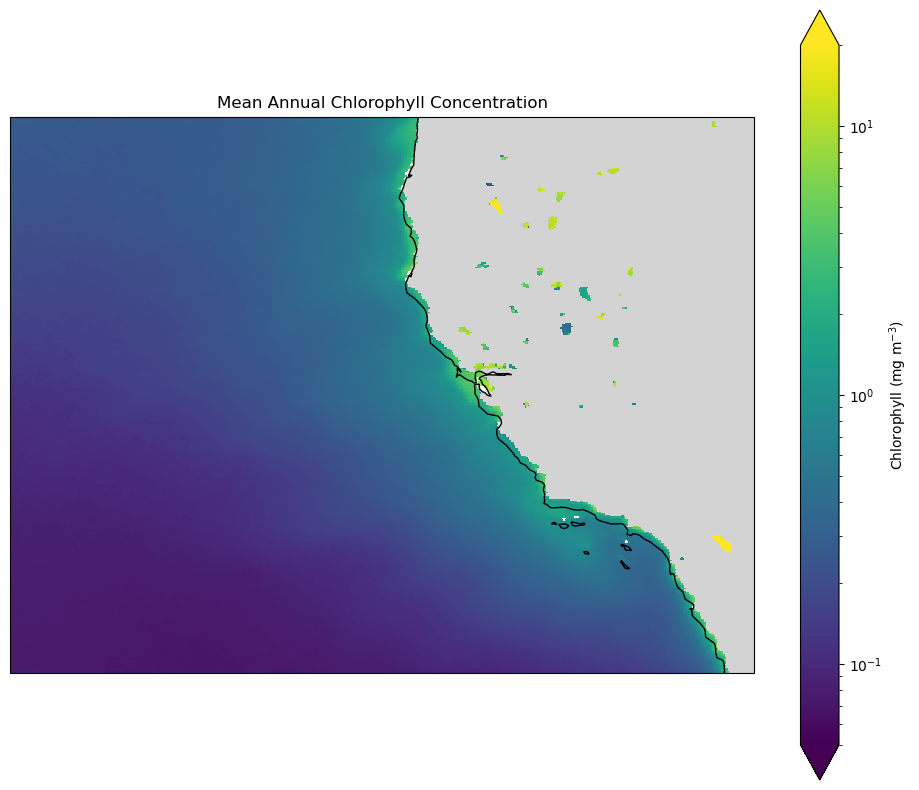

In [28]:
fig = plt.figure(figsize=(12,10))

ax = plt.axes(projection=ccrs.PlateCarree())

chl_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    norm=LogNorm(vmin=0.05, vmax=20),
    cbar_kwargs={"label": "Chlorophyll (mg m$^{-3}$)"}
)

ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

ax.set_extent([lon_min, lon_max, lat_min, lat_max])

ax.set_title("Mean Annual Chlorophyll Concentration")

plt.show()

In [33]:
chl = ds["chlor_a"]      # or whatever variable name appears
chl_mean = chl.mean(dim="time")

In [31]:
print(type(chl_region))
print(chl_region)

<class 'xarray.core.dataset.Dataset'>
<xarray.Dataset> Size: 4kB
Dimensions:  (time: 12, lat: 0, lon: 480)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 0B 
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:           

In [35]:
print("TYPE:", type(chl_region))
print("DIMS:", chl_region.dims if hasattr(chl_region, "dims") else "NO DIMS")
print(chl_region)

TYPE: <class 'xarray.core.dataset.Dataset'>
DIMS: FrozenMappingWarningOnValuesAccess({'time': 12, 'lat': 0, 'lon': 480})
<xarray.Dataset> Size: 4kB
Dimensions:  (time: 12, lat: 0, lon: 480)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 4kB -135.0 -134.9 -134.9 ... -115.1 -115.1 -115.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 0B 
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               19

In [14]:
print(ds.data_vars)

Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...


In [15]:
# --- select chlorophyll data properly ---
chl_region = ds["chlor_a"].sel(
    lat=slice(-60, -30),
    lon=slice(10, 40)
)

# --- convert to numeric array ---
monthly_clim = chl_region.astype("float32")

# --- monthly climatology ---
monthly_clim = monthly_clim.groupby("time.month").mean(dim="time")

# --- reduce resolution ---
monthly_clim = monthly_clim.coarsen(
    lat=4,
    lon=4,
    boundary="trim"
).mean()

In [13]:
g = monthly_clim.plot(
    col="month",
    col_wrap=4,
    figsize=(18,12),
    transform=ccrs.PlateCarree(),
    subplot_kws={"projection": ccrs.PlateCarree()},
    cmap="viridis",
    norm=LogNorm(vmin=0.05, vmax=10),
    cbar_kwargs={"label": "Chlorophyll (mg m$^{-3}$)"}
)

TypeError: No numeric data to plot.

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm

# --- load dataset ---
ds = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# --- select chlorophyll + region FIRST ---
chl_region = ds["CHL"].sel(
    lat=slice(-60, -30),
    lon=slice(10, 40)
)
# --- reduce resolution BEFORE climatology ---
chl_region = chl_region.coarsen(
    lat=4,
    lon=4,
    boundary="trim"
).mean()

# --- compute monthly climatology ---
monthly_clim = chl_region.groupby("time.month").mean(dim="time")

# --- plot ---
g = monthly_clim.plot(
    col="month",
    col_wrap=4,
    figsize=(18,12),
    transform=ccrs.PlateCarree(),
    subplot_kws={"projection": ccrs.PlateCarree()},
    cmap="viridis",
    norm=LogNorm(vmin=0.05, vmax=10),
    cbar_kwargs={"label": "Chlorophyll (mg m$^{-3}$)"},
    robust=True
)

# --- styling ---
for ax in g.axs.flat:
    ax.coastlines()
    ax.add_feature(cfeature.LAND, color="lightgray")
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

plt.suptitle("Monthly Climatological Chlorophyll", fontsize=18)

plt.show()

KeyError: "No variable named 'CHL'. Variables on the dataset include ['crs', 'chlor_a', 'time', 'lon', 'lat']"

TypeError: No numeric data to plot.

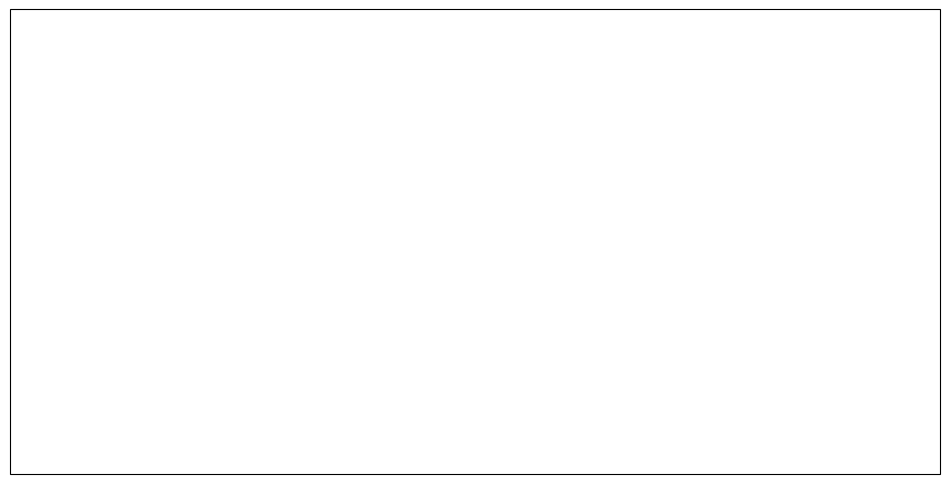

In [23]:
fig = plt.figure(figsize=(12,10))

ax = plt.axes(projection=ccrs.PlateCarree())

chl_mean.plot(
    ax=ax,
    cmap="viridis",
    norm=LogNorm(vmin=0.05, vmax=20),
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label":"Chlorophyll (mg m$^{-3}$)"}
)

ax.coastlines()
ax.add_feature(cfeature.LAND, color='lightgray')

ax.set_extent([-135,-115,30,45])

ax.set_title("Mean Annual Chlorophyll")

plt.show()
print(chl.data_vars)

In [24]:
print(chl.data_vars)

Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...


In [25]:
chl_mean = chl_region["CHL"].mean(dim="time")

KeyError: "No variable named 'CHL'. Variables on the dataset include ['crs', 'chlor_a', 'time', 'lon', 'lat']"